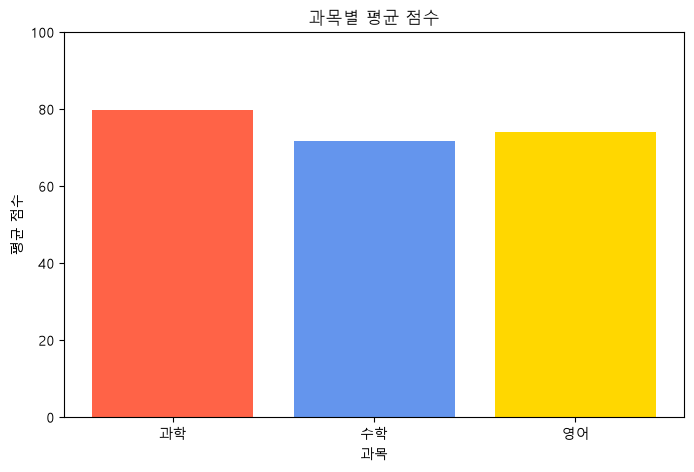

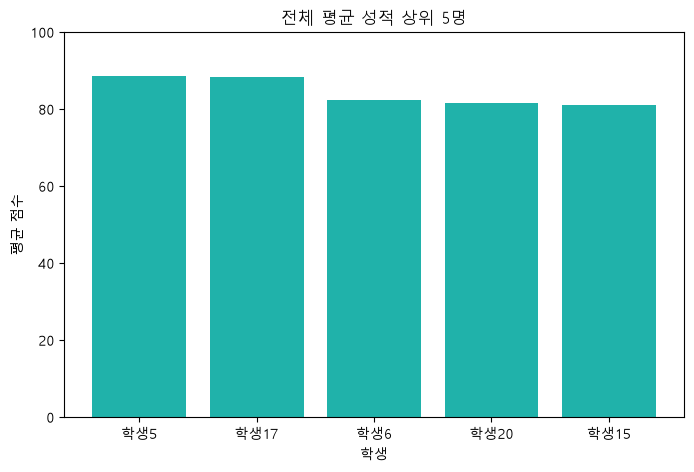

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# [환경 설정] Matplotlib 한글 폰트 깨짐 방지 
plt.rc('font', family='Malgun Gothic') # Windows 기본 한글 폰트 설정

# [클래스 정의] 학생 성적 통계 분석 및 시각화를 위한 클래스
class StudentScoreAnalysis:

    def __init__(self):
        """
        클래스 초기화 메서드: 분석에 필요한 기초 데이터를 생성하고 데이터프레임으로 변환합니다.
        """
        # 1-1. 학생 이름 데이터 생성: '학생1'부터 '학생20'까지 각 3번씩 반복 (총 60개)
        self.students_names = np.repeat([f'학생{i}' for i in range(1, 21)], 3)
        
        # 1-2. 성적 데이터 난수 생성: 과제 요구사항에 맞춰 50점 이상 100점 이하 범위로 지정 (총 60개)
        self.score_data = np.random.randint(50, 101, size=len(self.students_names))
        
        # 1-3. 과목 데이터 생성: 과제 요구사항에 맞춘 '수학', '영어', '과학' 리스트 패턴 생성 (총 60개)
        self.subjects = ['수학', '영어', '과학'] * 20 

        # 1-4. 생성된 numpy 배열들을 딕셔너리로 묶어 Pandas 데이터프레임(DataFrame) 생성
        self.df = pd.DataFrame({
            '학생': self.students_names, 
            '과목': self.subjects, 
            '점수': self.score_data
        })

    def analyze_and_visualize(self):
        """
        데이터 분석 및 시각화 메서드: 통계를 계산하고 2개의 막대 그래프를 독립적으로 출력합니다.
        """
        # 2-1. 과목별 통계 분석: '과목' 기준으로 그룹화하여 각 과목의 점수 평균(mean) 계산
        subject_mean = self.df.groupby('과목')['점수'].mean()

        # 2-2. 학생별 통계 분석: '학생' 기준으로 그룹화하여 각 학생의 전 과목 점수 평균 계산
        student_mean = self.df.groupby('학생')['점수'].mean()
        
        # 2-3. 상위 5명 정렬 및 추출: 학생별 평균 점수를 내림차순(ascending=False) 정렬 후 상위 5개(.head(5))만 슬라이싱
        top5_students = student_mean.sort_values(ascending=False).head(5)
        #print(top5_students)

        # 3. [시각화 1] 과목별 평균 점수 막대 그래프
        plt.figure(figsize=(8, 5)) # 그래프 크기 설정 (가로 8, 세로 5)
        
        # x축은 과목명(index), y축은 평균 점수(values)를 매칭하고 과목별 개별 색상 부여
        plt.bar(subject_mean.index, subject_mean.values, color=['tomato', 'cornflowerblue', 'gold'])
        
        # 그래프 세부 옵션(제목, 축 라벨, Y축 범위 고정) 설정
        plt.title('과목별 평균 점수')
        plt.xlabel('과목')
        plt.ylabel('평균 점수')
        plt.ylim(0, 100) # 점수 가독성을 위해 0점부터 100점까지 축 범위 제한
        plt.show()       # 첫 번째 그래프 화면 출력


        # 4. [시각화 2] 전체 평균 성적 상위 5명 막대 그래프
        plt.figure(figsize=(8, 5)) # 그래프 크기 설정 (가로 8, 세로 5)
        
        # x축은 상위 5명의 학생 이름(index), y축은 그 학생들의 평균 점수(values) 매칭
        plt.bar(top5_students.index, top5_students.values, color='lightseagreen')
        
        # 그래프 세부 옵션 설정
        plt.title('전체 평균 성적 상위 5명')
        plt.xlabel('학생')
        plt.ylabel('평균 점수')
        plt.ylim(0, 100)               # 점수 가독성을 위해 0점부터 100점까지 축 범위 제한
        plt.xticks(top5_students.index) # x축 레이블 위치에 학생 이름을 명시적으로 고정
        plt.show()                      # 두 번째 그래프 화면 출력

# ==========================================
# 시스템 실행 구조
# ==========================================
# StudentScoreAnalysis 클래스의 인스턴스(객체) 생성 및 초기화 수행
result = StudentScoreAnalysis()
    
# 인스턴스 메서드를 호출하여 통계 데이터 연산 및 2개의 막대 그래프 최종 출력
result.analyze_and_visualize()